# Simple MultiAI Agent Architecture 

In [2]:
import os 
from typing import TypedDict, Annotated, List, Literal 
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage 
from langchain_core.tools import tool 
from langchain_community.tools.tavily_search import TavilySearchResults 
from langgraph.graph import StateGraph, END 
from langchain.agents import create_agent 
from langgraph.checkpoint.memory import MemorySaver

C:\Users\manas\AppData\Local\Temp\ipykernel_22016\1348523967.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
c:\Users\manas\Documents\development\langgraph-learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [4]:
from langgraph.graph import StateGraph, END, MessagesState 
from langgraph.prebuilt import ToolNode 
from langgraph.checkpoint.memory import MemorySaver

In [5]:
## Define the state 
class AgentState(MessagesState): 
    next_agent: str # which agent should go next 

In [6]:
# Create simple tools 
@tool
def search_web(query:str)-> str: 
    """Search the web for information"""
    # Using Tavily for web search 
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)


@tool 
def write_summary(content: str)-> str: 
    """Write a summary of the provided content"""
    # Simpel summary generation 
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary

In [7]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("groq:openai/gpt-oss-120b")
llm 

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002926DC170E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002926DC17B60>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [8]:
# Define agent functions (simpler approach)
def researcher_agent(state: AgentState): 
    """Researcher agent that searches for information"""

    messages = state["messages"]

    # Add system message for context 
    system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")

    # Call LLM with tools 
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)

    # Return the response and route to writer 
    return {
        "messages": [response], 
        "next_agent": "writer"
    }

In [9]:
def writer_agent(state: AgentState): 
    """Writer agent that creates summaries"""

    messages = state["messages"]

    # Add system message for context 
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings")

    # simple completion without tools 
    response = llm.invoke([system_msg] + messages)

    return {
        "messages": [response], 
        "next_agent": "end"
    }

In [10]:
# Tool executor node 
def execute_tools(state: AgentState): 
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]

    # chekc if there are tool calls to execute 
    if hasattr(last_message, "tool_calls") and last_message.tool_calls: 
        # Create tool node and execute 
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response 

    # No tools to execute 
    return state

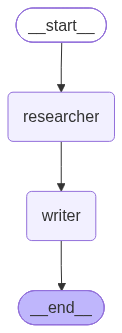

In [11]:
# Build graph 
workflow = StateGraph(MessagesState)

# Add nodes 
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)

# Define the flow 
workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", END)
final_workflow = workflow.compile()
final_workflow



In [12]:
response = final_workflow.invoke({"messages": "Research about the use case of agentic ai in business"})

BadRequestError: Error code: 400 - {'error': {'message': 'Tool choice is none, but model called a tool', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '{"name": "search_web", "arguments": {"query": "agentic AI business use cases", "top_n": 10, "source": "news"}}'}}

In [28]:
response["messages"][-1].content

'✍️ Writer: Report complete! See below for the full document.'

## Supervised Multi AI Agent Architecture 

In [13]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any 
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random 
from datetime import datetime

In [14]:
## State Defination 

# class SupervisorState(MessagesState): 
#     """State for the supervisor multi- agent system"""
#     current_age: str = ""
#     task_assignments: Dict[str, List[str]] = {} # Track what each agent should do 
#     agent_outputs: Dict[str, Any] = {} # Store outputs from each agent 
#     workflow_stage: str = "initial" # Track workflow progress 
#     iteration_count: int = 0
#     max_iterations: int = 10
#     final_output: str = ""


class SupervisorState(MessagesState):
    """State for the multi-agent system"""
    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""
    task_complete: bool = False
    current_task: str = ""

In [15]:
## Supervisor with Groq LLM 

from langchain_core.prompts import ChatPromptTemplate
def create_supervisor_chain():
    """Creates the supervisor decision chain"""
    
    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:
        
1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights  
3. Writer - Creates reports and summaries

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY the agent name (researcher/analyst/writer) or 'DONE'.
"""),
        ("human", "{task}")
    ])
    
    return supervisor_prompt | llm

In [16]:
def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM"""
    
    messages = state["messages"]
    task = messages[-1].content if messages else "No task"
    
    # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))
    
    # Get LLM decision
    chain = create_supervisor_chain()
    decision = chain.invoke({
        "task": task,
        "has_research": has_research,
        "has_analysis": has_analysis,
        "has_report": has_report
    })
    
    # Parse decision
    decision_text = decision.content.strip().lower()
    print(decision_text)
    
    # Determine next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_msg = "📋 Supervisor: Let's start with research. Assigning to Researcher..."
    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "📋 Supervisor: Research done. Time for analysis. Assigning to Analyst..."
    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "📋 Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    else:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: Task seems complete."
    
    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task
    }

In [17]:
# researcher agent 

def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information"""
    
    task = state.get("current_task", "research topic")
    
    # Create research prompt
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies
    
    Be concise but thorough."""
    
    # Get research from LLM
    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content
    
    # Create agent message
    agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data[:500]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor"
    }

In [18]:
# Analyst Agent 

def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research"""
    
    research_data = state.get("research_data", "")
    task = state.get("current_task", "")
    
    # Create analysis prompt
    analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

    Research Data:
    {research_data}

    Provide:
    1. Key insights and patterns
    2. Strategic implications
    3. Risks and opportunities
    4. Recommendations

    Focus on actionable insights related to: {task}"""
    
    # Get analysis from LLM
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis = analysis_response.content
    
    # Create agent message
    agent_message = f"📊 Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:400]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor"
    }

In [19]:
# Writer Agent 

def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report"""
    
    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")
    
    # Create writing prompt
    writing_prompt = f"""As a professional writer, create an executive report based on:

        Task: {task}

        Research Findings:
        {research_data[:1000]}

        Analysis:
        {analysis[:1000]}

        Create a well-structured report with:
        1. Executive Summary
        2. Key Findings  
        3. Analysis & Insights
        4. Recommendations
        5. Conclusion

        Keep it professional and concise."""
            
    # Get report from LLM
    report_response = llm.invoke([HumanMessage(content=writing_prompt)])
    report = report_response.content
            
    # Create final formatted report
    final_report = f"""
    📄 FINAL REPORT
    {'='*50}
    Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
    Topic: {task}
    {'='*50}

    {report}

    {'='*50}
    Report compiled by Multi-Agent AI System powered by Groq
    """
        
    return {
        "messages": [AIMessage(content=f"✍️ Writer: Report complete! See below for the full document.")],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True
    }

In [20]:
# Router function 

def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Routes to next agent based on state"""
    
    next_agent = state.get("next_agent", "supervisor")
    
    if next_agent == "end" or state.get("task_complete", False):
        return END
        
    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent
        
    return "supervisor"

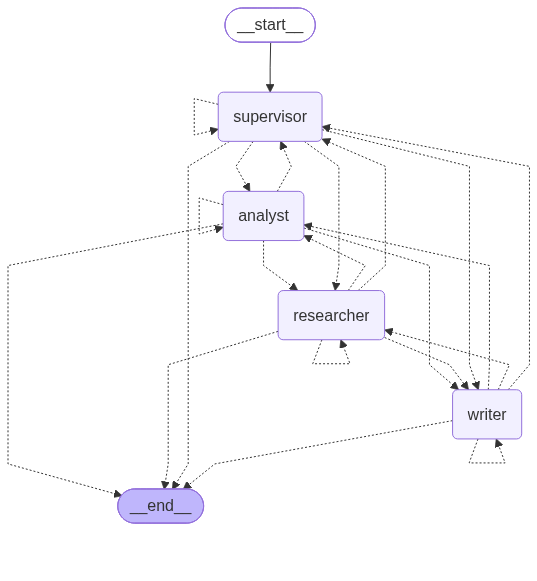

In [21]:
# Create workflow
workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

# Set entry point
workflow.set_entry_point("supervisor")

# Add routing
for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END
        }
    )

graph=workflow.compile()
graph

In [22]:
response = graph.invoke({"messages": HumanMessage(content= "What are the benifits and risks of AI in healthcare ? ")})

researcher
analyst
writer


In [23]:
response 

{'messages': [HumanMessage(content='What are the benifits and risks of AI in healthcare ? ', additional_kwargs={}, response_metadata={}, id='5d86b6c5-114e-426a-a49a-f671139b7b3d'),
  AIMessage(content="📋 Supervisor: Let's start with research. Assigning to Researcher...", additional_kwargs={}, response_metadata={}, id='46ebfe63-48f3-492f-bbe2-c51e009842aa', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="🔍 Researcher: I've completed the research on 'What are the benifits and risks of AI in healthcare ? '.\n\nKey findings:\n**AI in Healthcare – Benefits, Risks, and the State of the Field (2024‑2025)**  \n\n---\n\n## 1. Key Facts & Background  \n\n| Aspect | Detail |\n|--------|--------|\n| **Definition** | AI in healthcare = machine‑learning, deep‑learning, natural‑language processing (NLP), computer‑vision, and knowledge‑graph technologies applied to clinical, operational, or research tasks. |\n| **Market size** | Global AI‑in‑healthcare market was **≈\u202fUS\u202f$14.6\u20

## Multimodal RAG (PDF with Images)

In [24]:
import fitz  # PyMuPDF
from langchain_core.documents import Document
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import numpy as np
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage
from sklearn.metrics.pairwise import cosine_similarity
import os
import base64
import io
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

In [44]:
## clip model 
import os 
from dotenv import load_dotenv

## set up the environment 
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

## initialize the clipt model for unified embeddings 
clip_model=CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 42621.99it/s]


CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1

In [45]:
## Embedding functions 
def embed_image(image_data): 
    """Embeded image using CLIP"""
    if isinstance(image_data, str): # If path 
        image = Image.open(image_data).convert('RGB')
    else: # If PIL Image 
        image = image_data

    inputs = clip_processor(images=image, return_tensors="pt")

    with torch.no_grad(): 
        outputs = clip_model.get_image_features(**inputs)
        features = outputs.pooler_output if hasattr(outputs, "pooler_output") else outputs
        # Normalize embeddings to unit vector 
        features = features / features.norm(dim=1, keepdim=True)
        return features.squeeze().numpy()


def embed_text(text):
    """Embed text using CLIP."""
    inputs = clip_processor(
        text=text, 
        return_tensors="pt", 
        padding=True,
        truncation=True,
        max_length=77  # CLIP's max token length
    )
    with torch.no_grad():
        outputs = clip_model.get_text_features(**inputs)
        features = outputs.pooler_output if hasattr(outputs, "pooler_output") else outputs
        # Normalize embeddings
        features = features / features.norm(dim=-1, keepdim=True)
        return features.squeeze().numpy()

In [46]:
## Process PDF 
pdf_path = "multimodal_sample.pdf"
doc=fitz.open(pdf_path)
#Storage for all documents and embeddings 
all_docs = []
all_embeddings = []
image_data_store = {}# store actual image for LLM 

# Text Splitter 
splitter = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 100)


In [47]:
doc 

Document('multimodal_sample.pdf')

In [48]:
for i,page in enumerate(doc):
    ## process text
    text=page.get_text()
    if text.strip():
        ##create temporary document for splitting
        temp_doc = Document(page_content=text, metadata={"page": i, "type": "text"})
        text_chunks = splitter.split_documents([temp_doc])

        #Embed each chunk using CLIP
        for chunk in text_chunks:
            embedding = embed_text(chunk.page_content)
            all_embeddings.append(embedding)
            all_docs.append(chunk)



    ## process images
    ##Three Important Actions:

    ##Convert PDF image to PIL format
    ##Store as base64 for GPT-4V (which needs base64 images)
    ##Create CLIP embedding for retrieval

    for img_index, img in enumerate(page.get_images(full=True)):
        try:
            xref = img[0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image["image"]
            
            # Convert to PIL Image
            pil_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
            
            # Create unique identifier
            image_id = f"page_{i}_img_{img_index}"
            
            # Store image as base64 for later use with GPT-4V
            buffered = io.BytesIO()
            pil_image.save(buffered, format="PNG")
            img_base64 = base64.b64encode(buffered.getvalue()).decode()
            image_data_store[image_id] = img_base64
            
            # Embed image using CLIP
            embedding = embed_image(pil_image)
            all_embeddings.append(embedding)
            
            # Create document for image
            image_doc = Document(
                page_content=f"[Image: {image_id}]",
                metadata={"page": i, "type": "image", "image_id": image_id}
            )
            all_docs.append(image_doc)
            
        except Exception as e:
            print(f"Error processing image {img_index} on page {i}: {e}")
            continue

doc.close()

In [40]:
all_docs

[Document(metadata={'page': 0, 'type': 'text'}, page_content='Annual Revenue Overview\nThis document summarizes the revenue trends across Q1, Q2, and Q3. As illustrated in the chart\nbelow, revenue grew steadily with the highest growth recorded in Q3.\nQ1 showed a moderate increase in revenue as new product lines were introduced. Q2 outperformed\nQ1 due to marketing campaigns. Q3 had exponential growth due to global expansion.'),
 Document(metadata={'page': 0, 'type': 'image', 'image_id': 'page_0_img_0'}, page_content='[Image: page_0_img_0]')]

In [49]:
# Create unified FAISS veector store with CLIP embeddings 
embeddings_array = np.array(all_embeddings)
embeddings_array


array([[-0.00267245,  0.01283   , -0.05183139, ..., -0.0038509 ,
         0.02977717, -0.00010682],
       [ 0.01732337, -0.0132769 , -0.0242703 , ...,  0.08994054,
        -0.00272156,  0.03253038]], shape=(2, 512), dtype=float32)

In [50]:
# create custom FAISS index since we have precomputed embeddings 
# here we have also stored the actual text chunk with the vector embeddings as well 
vector_store = FAISS.from_embeddings(
    text_embeddings=[(doc.page_content, emb) for doc, emb in zip(all_docs, embeddings_array)], 
    embedding=None, 
    metadatas=[doc.metadata for doc in all_docs] # this is used to store the location from where those chunks came from 
)
vector_store 

`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


In [66]:
llm = init_chat_model("groq:qwen/qwen3.6-27b")  # vision-capable model — gpt-oss-120b does not support image input
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.3.15'}}, client=<groq.resources.chat.completions.Completions object at 0x00000292A5CB43E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000292A586EEA0>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [67]:
def retrieve_multimodal(query, k=5): 
    """Unified retrieval using CLIP embeddings for both text and images"""
    # Embed query using CLIP 
    query_embedding = embed_text(query)

    # Search based on the query embeddings 
    # so the k over here returns the top k nearest neighbors (5 best matched results to the query )
    results = vector_store.similarity_search_by_vector(embedding=query_embedding, k=k)


    return results 

In [68]:
def create_multimodal_message(query, retrieved_docs): 
    """Create a message with both text and images for GPT-4V"""
    content = []

    # Add the query 
    content.append({
        "type": "text", 
        "text": f"Question: {query}\n\nContext:\n"
    })

    # Separate text and image documents 
    text_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "text"]
    image_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "image"]

    # Add text content 
    if text_docs: 
        text_context = '\n\n'.join([
            f"[Page {doc.metadata['page']}]: {doc.page_content}"
            for doc in text_docs
        ])
        content.append({
            "type": "text", 
            "text": f"Text excerpts: \n{text_context}\n"
        })

    # Add images
    for doc in image_docs:
        image_id = doc.metadata.get("image_id")
        if image_id and image_id in image_data_store:
            content.append({
                "type": "text",
                "text": f"\n[Image from page {doc.metadata['page']}]:\n"
            })
            content.append({
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{image_data_store[image_id]}"
                }
            })


    # Add instruction 
    content.append({
        "type": "text", 
        "text": "\n\nPlease answer the question based on the provided text and images"
    })


    return HumanMessage(content=content)

In [69]:
def multimodal_pdf_rag_pipeline(query):
    """Main pipeline for multimodal RAG."""
    # Retrieve relevant documents
    context_docs = retrieve_multimodal(query, k=5)
    
    # Create multimodal message
    message = create_multimodal_message(query, context_docs)
    
    # Get response from GPT-4V
    response = llm.invoke([message])
    
    # Print retrieved context info
    print(f"\nRetrieved {len(context_docs)} documents:")
    for doc in context_docs:
        doc_type = doc.metadata.get("type", "unknown")
        page = doc.metadata.get("page", "?")
        if doc_type == "text":
            preview = doc.page_content[:100] + "..." if len(doc.page_content) > 100 else doc.page_content
            print(f"  - Text from page {page}: {preview}")
        else:
            print(f"  - Image from page {page}")
    print("\n")
    
    return response.content

In [71]:
if __name__ == "__main__": 
    # Example queries 
    queries = [
        "What does the chart on page 1 show about revenue trends ? ",
        "summarize the main findings from the document", 
        "What visual elements are present in the doucment?"
    ]


    for query in queries: 
        print(f"\nQuery: {query}")
        print("-" * 50)
        answer = multimodal_pdf_rag_pipeline(query)
        print(f"Answer: {answer}")
        print("=" * 70)


Query: What does the chart on page 1 show about revenue trends ? 
--------------------------------------------------

Retrieved 2 documents:
  - Text from page 0: Annual Revenue Overview
This document summarizes the revenue trends across Q1, Q2, and Q3. As illust...
  - Image from page 0


Answer: 
<think>
The user wants to know what the chart on page 1 shows about revenue trends.

1.  **Analyze the Request:** The user is asking about a "chart on page 1".
2.  **Analyze the Context:**
    *   **Page 0 Text:** Describes revenue trends across Q1, Q2, and Q3. It mentions "As illustrated in the chart below..." and describes steady growth, highest growth in Q3, moderate increase in Q1, outperformance in Q2, and exponential growth in Q3.
    *   **Image from Page 0:** Shows a bar chart with three bars: Blue (shortest), Green (medium), Red (tallest). This aligns with the text description (Q1 < Q2 < Q3).
    *   **Page 1:** There is no text or image provided for Page 1. The prompt only provide